# 1. Problem Statement:

## INX Future Inc Employee Performance:

INX Future Inc , (referred as INX ) , is one of the leading data analytics and automation solutions provider
with over 15 years of global business presence. INX is consistently rated as top 20 best employers past 5
years. INX human resource policies are considered as employee friendly and widely perceived as best
practices in the industry.

Recent years, the employee performance indexes are not healthy and this is becoming a growing
concerns among the top management. There has been increased escalations on service delivery and
client satisfaction levels came down by 8 percentage points.

CEO, Mr. Brain, knows the issues but concerned to take any actions in penalizing non-performing employees as this would affect the employee morale of all the employees in general and may further reduce the performance.

# 2. Importing Basic Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, f1_score, recall_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

# 3. Loading the data

In [2]:
df = pd.read_excel('INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls')
df

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3


# Insight:

The data for training the model was collected from the company INX Future Inc. The data collected included 1200 employee’s performance appraisal records, described by 28 parameters. the parameters show the different attributes of an employee based on which the prediction is to be made.

# 4. Domain Analysis:

* EmpNumber: Employee Number, a unique identifier assigned to each employee.
* Age: The age of the employee.
* Gender: The gender of the employee.
* EductionBackground: Education Background, referring to the academic qualifications or educational history of the employee.
* MaritalStatus: The marital status of the employee.
* EmpDepartment: The department or division in which the employee works.
* EmpJobRole: The specific role or position/job title of the employee.
* BusinessTravelFrequency: The frequency with which the employee travels for business purposes.
* DistanceFromHome: The distance in miles between the employee's home and workplace.
* EmpEducationLevel: The education level attained by the employee.
* EmpEnvironmentSatisfaction: Employee's satisfaction with their work environment.
* EmpHourlyRate: The hourly rate of pay for the employee.
* EmpJobInvolvement: The level of involvement or engagement the employee has in their job.
* EmpJobLevel: The hierarchical level or rank of the employee within the organization.
* EmpJobSatisfaction: Employee's satisfaction with their job.
* NumCompaniesWorked: The number of companies the employee has worked for in the past.
* OverTime: Whether the employee is involved in overtime work.
* EmpLastSalaryHikePercent: The percentage increase in the employee's salary during the last salary hike.
* EmpRelationshipSatisfaction: Employee's satisfaction with their relationships at work.
* TotalWorkExperienceInYears: The total number of years of work experience the employee has.
* TrainingTimesLastYear: The number of times the employee underwent training in the last year.
* EmpWorkLifeBalance: Employee's perception of the balance between work and personal life.
* ExperienceYearsAtThisCompany: The number of years the employee has worked at the current company.
* ExperienceYearsInCurrentRole: The number of years the employee has been in their current role.
* YearsSinceLastPromotion: The number of years since the employee's last promotion.
* YearsWithCurrManager: The number of years the employee has been working with their current manager.
* Attrition: The employee's status regarding attrition, which typically refers to the act of leaving a job or position.
* PerformanceRating: The performance rating assigned to the employee, indicating their level of job performance.

# 5.Basic Checks¶

In [3]:
# checking the first 5 rows of the list.
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [4]:
# checking the last 5 rows of the list.
df.tail()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1195,E100992,27,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,3,1,...,2,6,3,3,6,5,0,4,No,4
1196,E100993,37,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,10,2,...,1,4,2,3,1,0,0,0,No,3
1197,E100994,50,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,28,1,...,3,20,3,3,20,8,3,8,No,3
1198,E100995,34,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,9,3,...,2,9,3,4,8,7,7,7,No,3
1199,E100998,24,Female,Life Sciences,Single,Sales,Sales Executive,Travel_Rarely,3,2,...,1,4,3,3,2,2,2,0,Yes,2


In [5]:
#checking the shape of the list (i.e no. of rows & no. of columns)
df.shape

(1200, 28)

In [6]:
# checking the names of the columns
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [7]:
# checking the categorical datatypes
df.select_dtypes (include= "object")

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
0,E1001000,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,No,No
1,E1001006,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,No,No
2,E1001007,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,Yes,No
3,E1001009,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,No,No
4,E1001010,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,No,No
...,...,...,...,...,...,...,...,...,...
1195,E100992,Female,Medical,Divorced,Sales,Sales Executive,Travel_Frequently,Yes,No
1196,E100993,Male,Life Sciences,Single,Development,Senior Developer,Travel_Rarely,No,No
1197,E100994,Male,Medical,Married,Development,Senior Developer,Travel_Rarely,Yes,No
1198,E100995,Female,Medical,Single,Data Science,Data Scientist,Travel_Rarely,No,No


In [8]:
# checking the numerical datatypes
df.select_dtypes (include= "int64")

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
0,32,10,3,4,55,3,2,4,1,12,4,10,2,2,10,7,0,8,3
1,47,14,4,4,42,3,2,1,2,12,4,20,2,3,7,7,1,7,3
2,40,5,4,4,48,2,3,1,5,21,3,20,2,3,18,13,1,12,4
3,41,10,4,2,73,2,5,4,3,15,2,23,2,2,21,6,12,6,3
4,60,16,4,1,84,3,2,1,8,14,4,10,1,3,2,2,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,27,3,1,4,71,4,2,4,1,20,2,6,3,3,6,5,0,4,4
1196,37,10,2,4,80,4,1,4,3,17,1,4,2,3,1,0,0,0,3
1197,50,28,1,4,74,4,1,3,1,11,3,20,3,3,20,8,3,8,3
1198,34,9,3,4,46,2,3,2,1,14,2,9,3,4,8,7,7,7,3


In [9]:
# checking the value counts of Age column
df.value_counts('Age')

Age
34    71
35    64
36    60
31    57
29    51
38    48
40    46
32    46
33    46
27    43
30    42
37    41
28    39
42    36
45    36
26    33
41    32
39    31
44    30
50    28
43    26
46    24
25    24
49    21
24    20
47    20
55    17
48    16
54    16
22    15
52    15
53    15
51    14
21    11
56    11
58    11
23     9
18     8
19     8
20     6
59     6
57     4
60     3
dtype: int64

In [10]:
# checking the value counts of EmpNumber column
df.value_counts('Gender')

Gender
Male      725
Female    475
dtype: int64

In [11]:
# checking the value counts of EducationBackground column
df.value_counts('EducationBackground')

EducationBackground
Life Sciences       492
Medical             384
Marketing           137
Technical Degree    100
Other                66
Human Resources      21
dtype: int64

In [12]:
# checking the value counts of MaritalStatus column
df.value_counts('MaritalStatus')

MaritalStatus
Married     548
Single      384
Divorced    268
dtype: int64

In [13]:
# checking the value counts of EmpDepartment column
df.value_counts('EmpDepartment')

EmpDepartment
Sales                     373
Development               361
Research & Development    343
Human Resources            54
Finance                    49
Data Science               20
dtype: int64

In [14]:
# checking the value counts of EmpJobRole column
df.value_counts('EmpJobRole')

EmpJobRole
Sales Executive              270
Developer                    236
Manager R&D                   94
Research Scientist            77
Sales Representative          69
Laboratory Technician         64
Senior Developer              52
Manager                       51
Finance Manager               49
Human Resources               45
Technical Lead                38
Manufacturing Director        33
Healthcare Representative     33
Data Scientist                20
Research Director             19
Business Analyst              16
Senior Manager R&D            15
Delivery Manager              12
Technical Architect            7
dtype: int64

In [15]:
# checking the value counts of BusinessTravelFrequency column
df.value_counts('BusinessTravelFrequency')

BusinessTravelFrequency
Travel_Rarely        846
Travel_Frequently    222
Non-Travel           132
dtype: int64

In [16]:
# checking the value counts of DistanceFromHome column
df.value_counts('DistanceFromHome')

DistanceFromHome
2     184
1     170
8      69
3      67
9      66
10     66
7      65
5      54
4      51
6      46
11     25
16     25
18     24
24     23
29     23
23     22
26     22
28     20
20     19
25     19
19     18
14     17
17     17
22     17
15     17
12     16
21     15
13     14
27      9
dtype: int64

In [17]:
# checking the value counts of DistanceFromHome column
df.value_counts('Attrition')

Attrition
No     1022
Yes     178
dtype: int64

In [18]:
# Information about a data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [19]:
# Checking the table of descriptive statistics for numerical column
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


# 6. Explanatory Data Analaysis(EDA)


  ### A. Univariate

In [20]:
!pip install sweetviz #installing sweetviz

Defaulting to user installation because normal site-packages is not writeable


ERROR: Invalid requirement: '#installing'


In [21]:
import sweetviz as sv 

my_report = sv.analyze(df)
my_report.show_html() 

                                             |                                             | [  0%]   00:00 ->…

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


# Insight:
1. Age: Age is a continuous column and it is skewed.
2. Gender: Male employees are more as compared to female employees.
3. EducationBackground: Most of the employees educational background is Lifescience.
4. MaritalStatus: Most of the employees are married and few of them are divorced.
5. EmpDepartment: Most of the employees belongs to sales department and few of them belongs to Human Resourcces Department.
6. EmpJobRole: Most of the employees have the jobrole of sale executive.
7. BusinessTravelFrequency: 70% of the employees travels very rarely while 10% of the employees are non traveller
8. DistanceFromHome: Most of the employees stay very near to there office area.
9. NumCompaniesWorked: Maximum of employees has 1year of experience and very few has 8-9years of experience.
10. OverTime: Most Employees are not ready to do overtime.

## B. Bivariate:
### Checking relationship of all variables with respect to target variable 

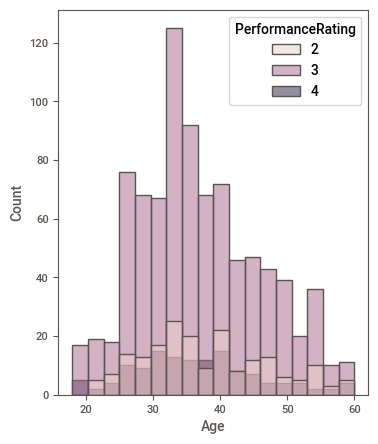

In [22]:
plt.figure(figsize=(4,5))
sns.histplot(x='Age',hue='PerformanceRating', data=df)
plt.show()

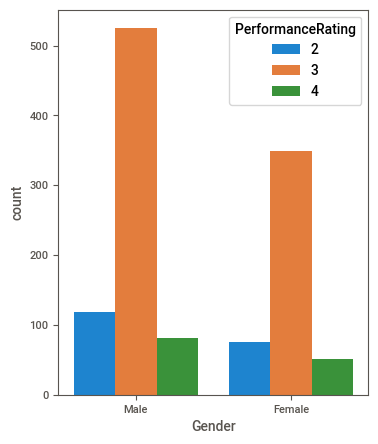

In [23]:
plt.figure(figsize=(4,5))
sns.countplot(x='Gender',hue='PerformanceRating', data=df)
plt.show()

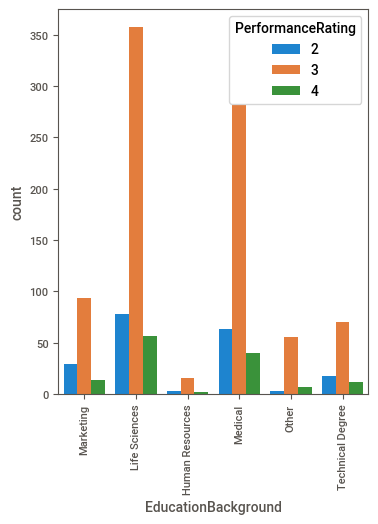

In [24]:
plt.figure(figsize=(4,5))
sns.countplot(x='EducationBackground',hue='PerformanceRating', data=df)
plt.xticks(rotation=90)
plt.show()

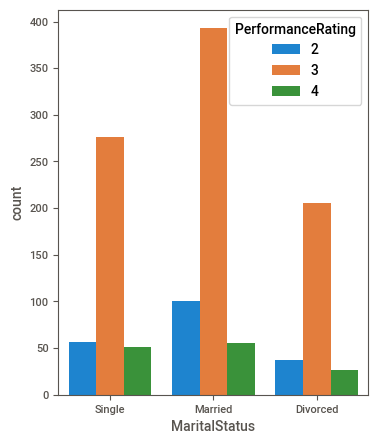

In [25]:
plt.figure(figsize=(4,5))
sns.countplot(x='MaritalStatus',hue='PerformanceRating', data=df)
plt.show()

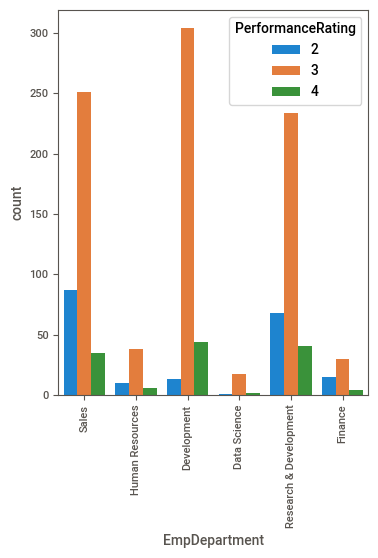

In [26]:
plt.figure(figsize=(4,5))
sns.countplot(x='EmpDepartment',hue='PerformanceRating', data=df)
plt.xticks(rotation=90)
plt.show()

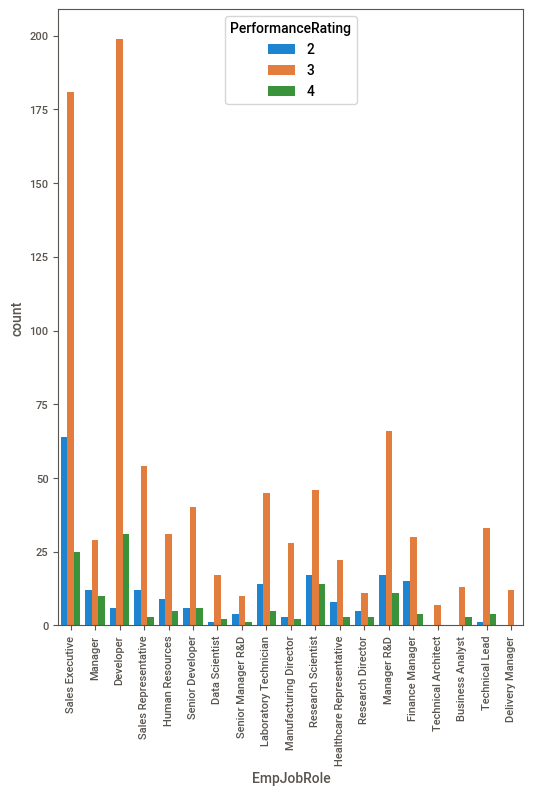

In [27]:
plt.figure(figsize=(6,8))
sns.countplot(x='EmpJobRole',hue='PerformanceRating', data=df)
plt.xticks(rotation=90)
plt.show()

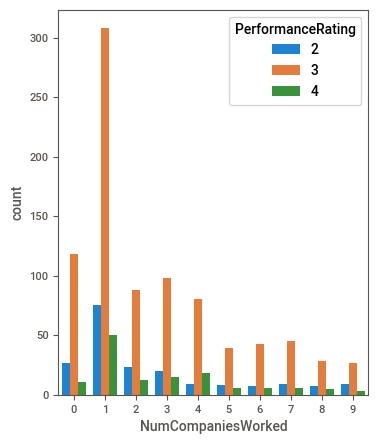

In [28]:
plt.figure(figsize=(4,5))
sns.countplot(x='NumCompaniesWorked',hue='PerformanceRating', data=df)
plt.show()


# 7. Data Preprocessing

### A. Checking missing values & Handling them

In [29]:
df.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

### B. Checking duplicate values and handling them

In [30]:
df.duplicated().sum()

0

## Insight:

* There is no missing and duplicates values.

# 8. Feature Engineering

### A. Converting Categorical column to numerical

In [31]:
lc = LabelEncoder()

df.Gender=lc.fit_transform(df.Gender)
df.EducationBackground=lc.fit_transform(df.EducationBackground)
df.MaritalStatus=lc.fit_transform(df.MaritalStatus)
df.EmpDepartment=lc.fit_transform(df.EmpDepartment)  
df.EmpJobRole=lc.fit_transform(df.EmpJobRole)
df.BusinessTravelFrequency=lc.fit_transform(df.BusinessTravelFrequency)  
df.OverTime=lc.fit_transform(df.OverTime)
df.Attrition=lc.fit_transform(df.Attrition)  

In [32]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,1,2,2,5,13,2,10,3,...,4,10,2,2,10,7,0,8,0,3
1,E1001006,47,1,2,2,5,13,2,14,4,...,4,20,2,3,7,7,1,7,0,3
2,E1001007,40,1,1,1,5,13,1,5,4,...,3,20,2,3,18,13,1,12,0,4
3,E1001009,41,1,0,0,3,8,2,10,4,...,2,23,2,2,21,6,12,6,0,3
4,E1001010,60,1,2,2,5,13,2,16,4,...,4,10,1,3,2,2,2,2,0,3


### B. Dropping irrelevent columns:

In [33]:
df.drop(['EmpNumber'], axis= True, inplace= True) # Dropping the first columns as it is of no use for analysis

In [34]:
df.columns

Index(['Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

### C. Correlation

In [35]:
df.corr()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
Age,1.000000,-0.040107,-0.055905,-0.098368,-0.000104,-0.037665,0.040579,0.020937,0.207313,0.013814,...,0.049749,0.680886,-0.016053,-0.019563,0.318852,0.217163,0.228199,0.205098,-0.189317,-0.040164
Gender,-0.040107,1.000000,0.009922,-0.042169,-0.010925,0.011332,-0.043608,-0.001507,-0.022960,0.000033,...,0.030707,-0.061055,-0.057654,0.015793,-0.030392,-0.031823,-0.021575,-0.036643,0.035758,-0.001780
EducationBackground,-0.055905,0.009922,1.000000,-0.001097,-0.026874,-0.012325,0.012382,-0.013919,-0.047978,0.045028,...,0.005652,-0.027929,0.051596,0.022890,-0.009887,-0.003215,0.014277,0.002767,0.027161,0.005607
MaritalStatus,-0.098368,-0.042169,-0.001097,1.000000,0.067272,0.038023,0.028520,-0.019148,0.026737,-0.032467,...,0.026410,-0.093537,0.026045,0.014154,-0.075728,-0.076663,-0.052951,-0.061908,0.162969,0.024172
EmpDepartment,-0.000104,-0.010925,-0.026874,0.067272,1.000000,0.568973,-0.045233,0.007707,0.019175,-0.019237,...,-0.050286,0.016065,0.016438,0.068875,0.047677,0.069602,0.052315,0.033850,0.048006,-0.162615
EmpJobRole,-0.037665,0.011332,-0.012325,0.038023,0.568973,1.000000,-0.086251,0.022939,-0.016792,0.044612,...,-0.043067,-0.049529,0.004452,-0.007519,-0.009047,0.019383,0.012190,-0.004504,0.037508,-0.096209
BusinessTravelFrequency,0.040579,-0.043608,0.012382,0.028520,-0.045233,-0.086251,1.000000,-0.020935,0.002064,0.012267,...,-0.032705,0.042736,0.006720,-0.040969,-0.015029,-0.006541,-0.020824,-0.028073,0.007217,-0.031025
DistanceFromHome,0.020937,-0.001507,-0.013919,-0.019148,0.007707,0.022939,-0.020935,1.000000,0.045856,-0.017719,...,-0.009509,0.027306,-0.032082,-0.044788,0.021908,0.019898,0.013246,0.017860,0.063248,-0.046142
EmpEducationLevel,0.207313,-0.022960,-0.047978,0.026737,0.019175,-0.016792,0.002064,0.045856,1.000000,-0.037103,...,-0.016690,0.151062,-0.013674,0.010276,0.076332,0.066672,0.054313,0.088988,-0.049118,0.020529
EmpEnvironmentSatisfaction,0.013814,0.000033,0.045028,-0.032467,-0.019237,0.044612,0.012267,-0.017719,-0.037103,1.000000,...,-0.010504,-0.012894,0.001192,-0.000262,-0.000561,0.025491,0.010732,-0.011702,-0.123490,0.395561


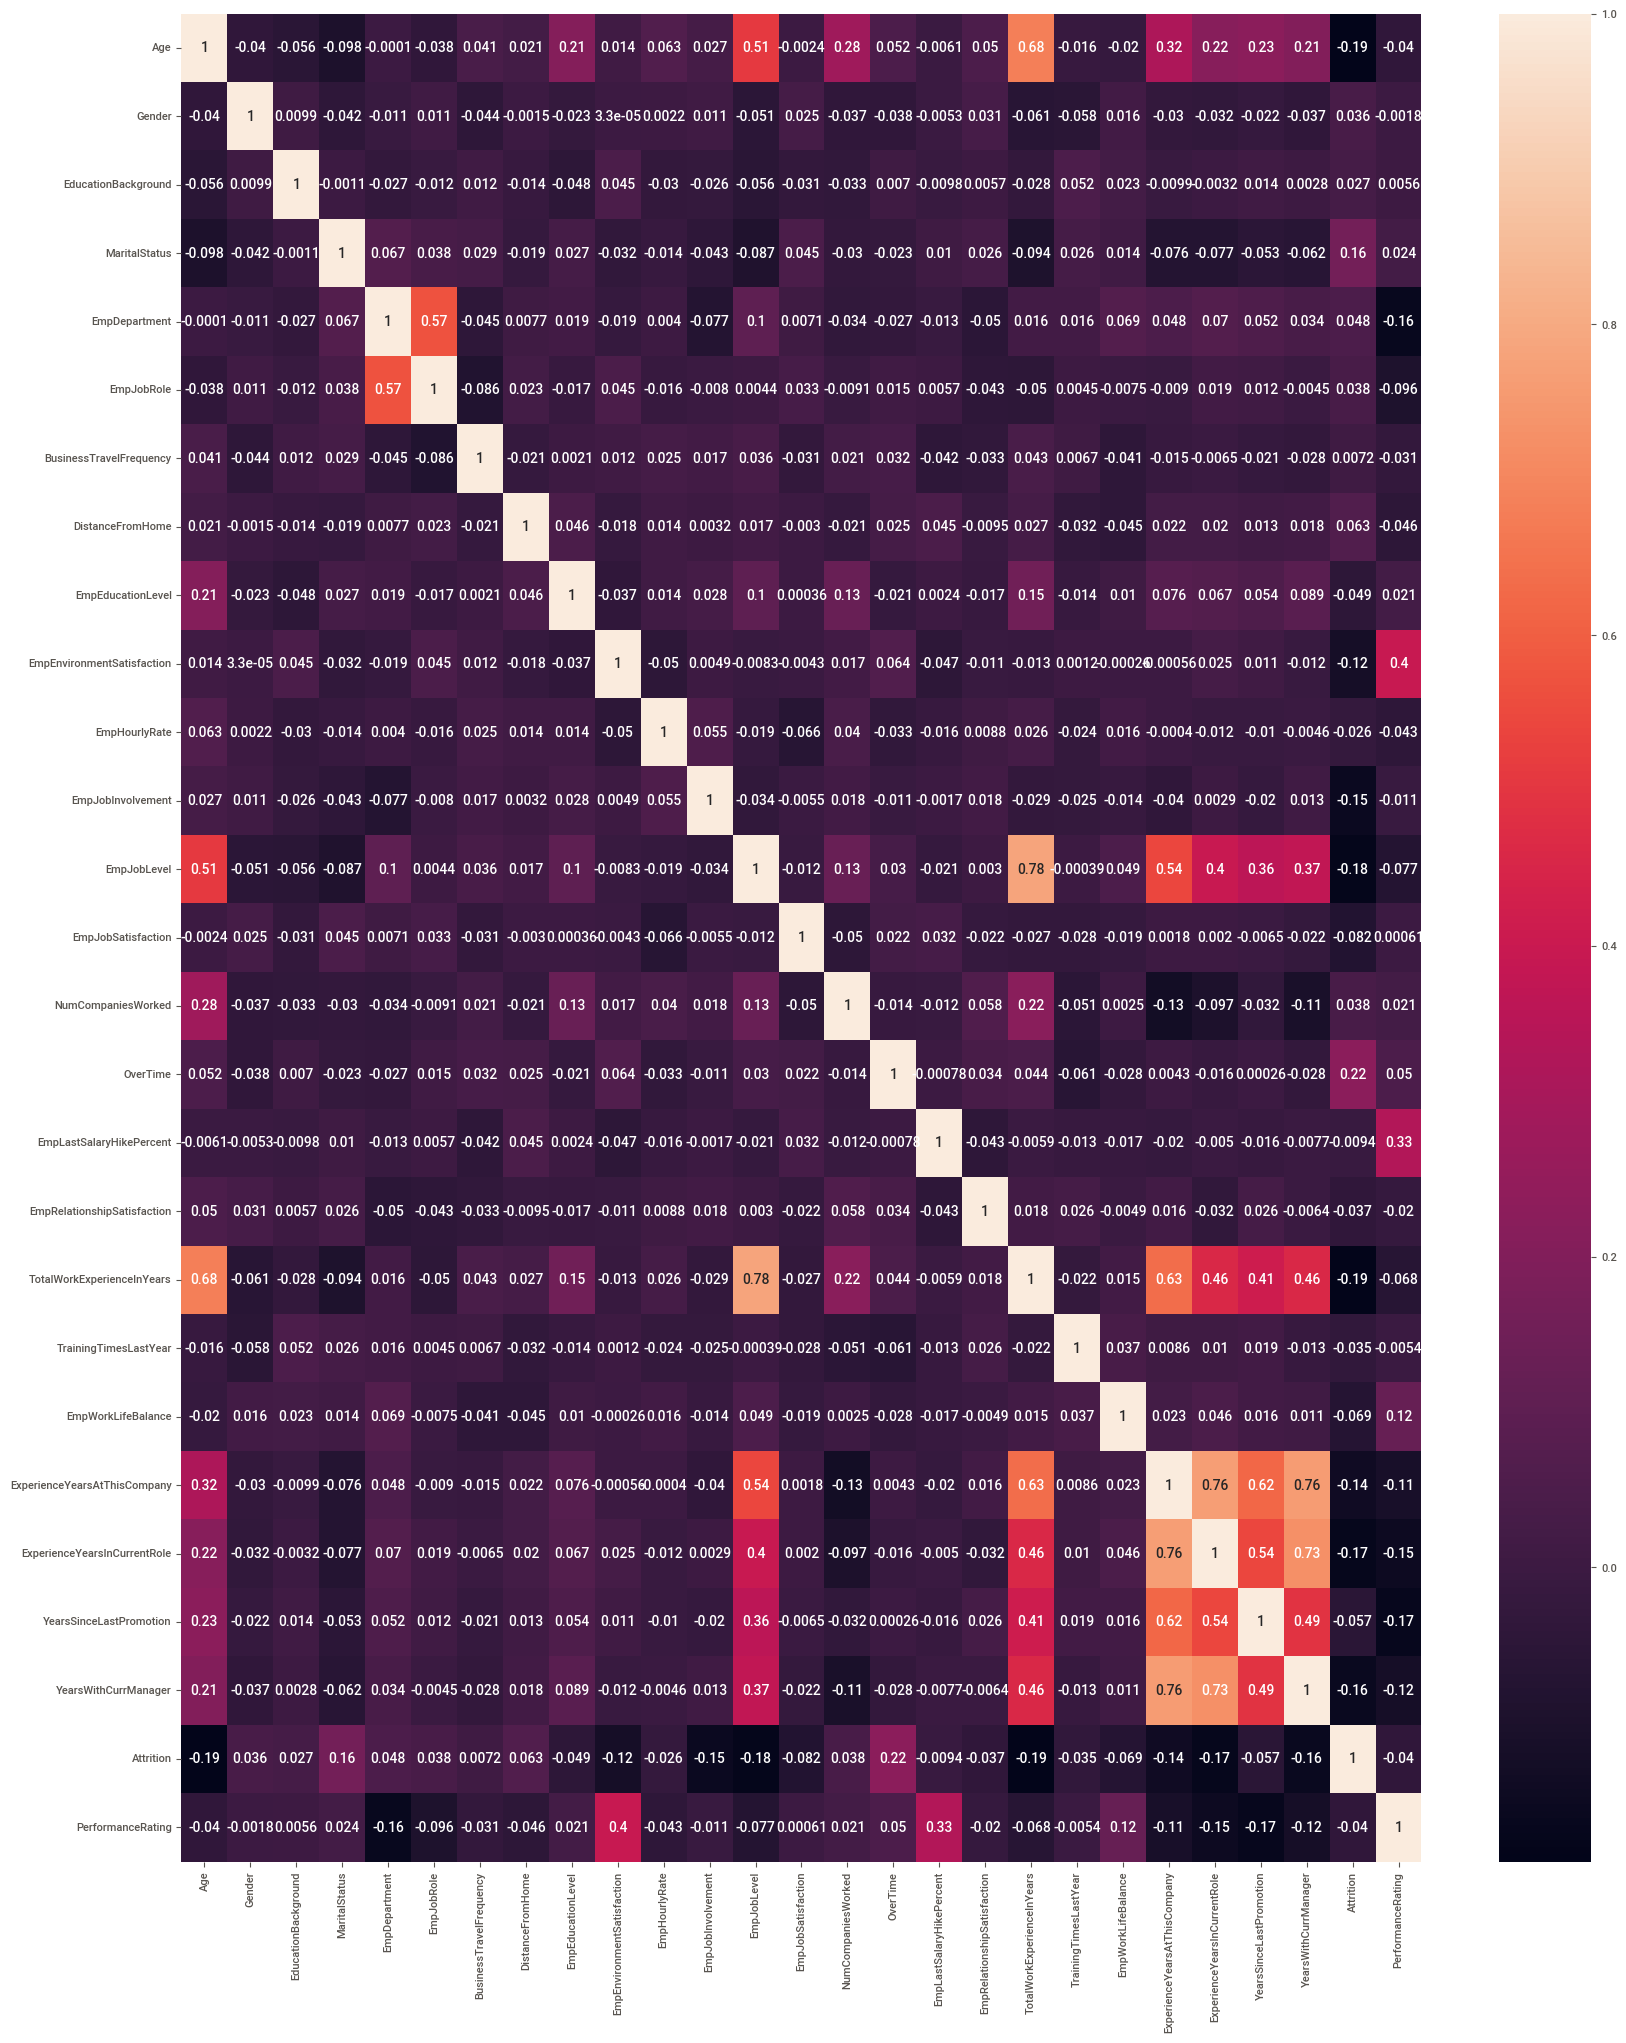

In [36]:
plt.figure(figsize=(20,24))
sns.heatmap(df.corr(), annot= True)
plt.show()

# Insights:

* Since we have lots of high correlated columns, we have to drop some columns
* We have high correlation between Age and Total Work Experience Years.
* We also have high correlation between EmpJobLevel and Total Work Experience Years.
* We have high correlation between Total Work Experience Years and experience Year at this company.
* we have high correlation between experience year at this company and Experience year in current role.
* We have high correlation between experience year at this company and Year Since Last Promotion.
* We have high correlation between experience year at this company and Year with curr manager.
* We have high correlation between Experience year in current role and Year with curr manager.

In [37]:
df.drop(['TotalWorkExperienceInYears','ExperienceYearsAtThisCompany','ExperienceYearsInCurrentRole'], axis= True, inplace= True)

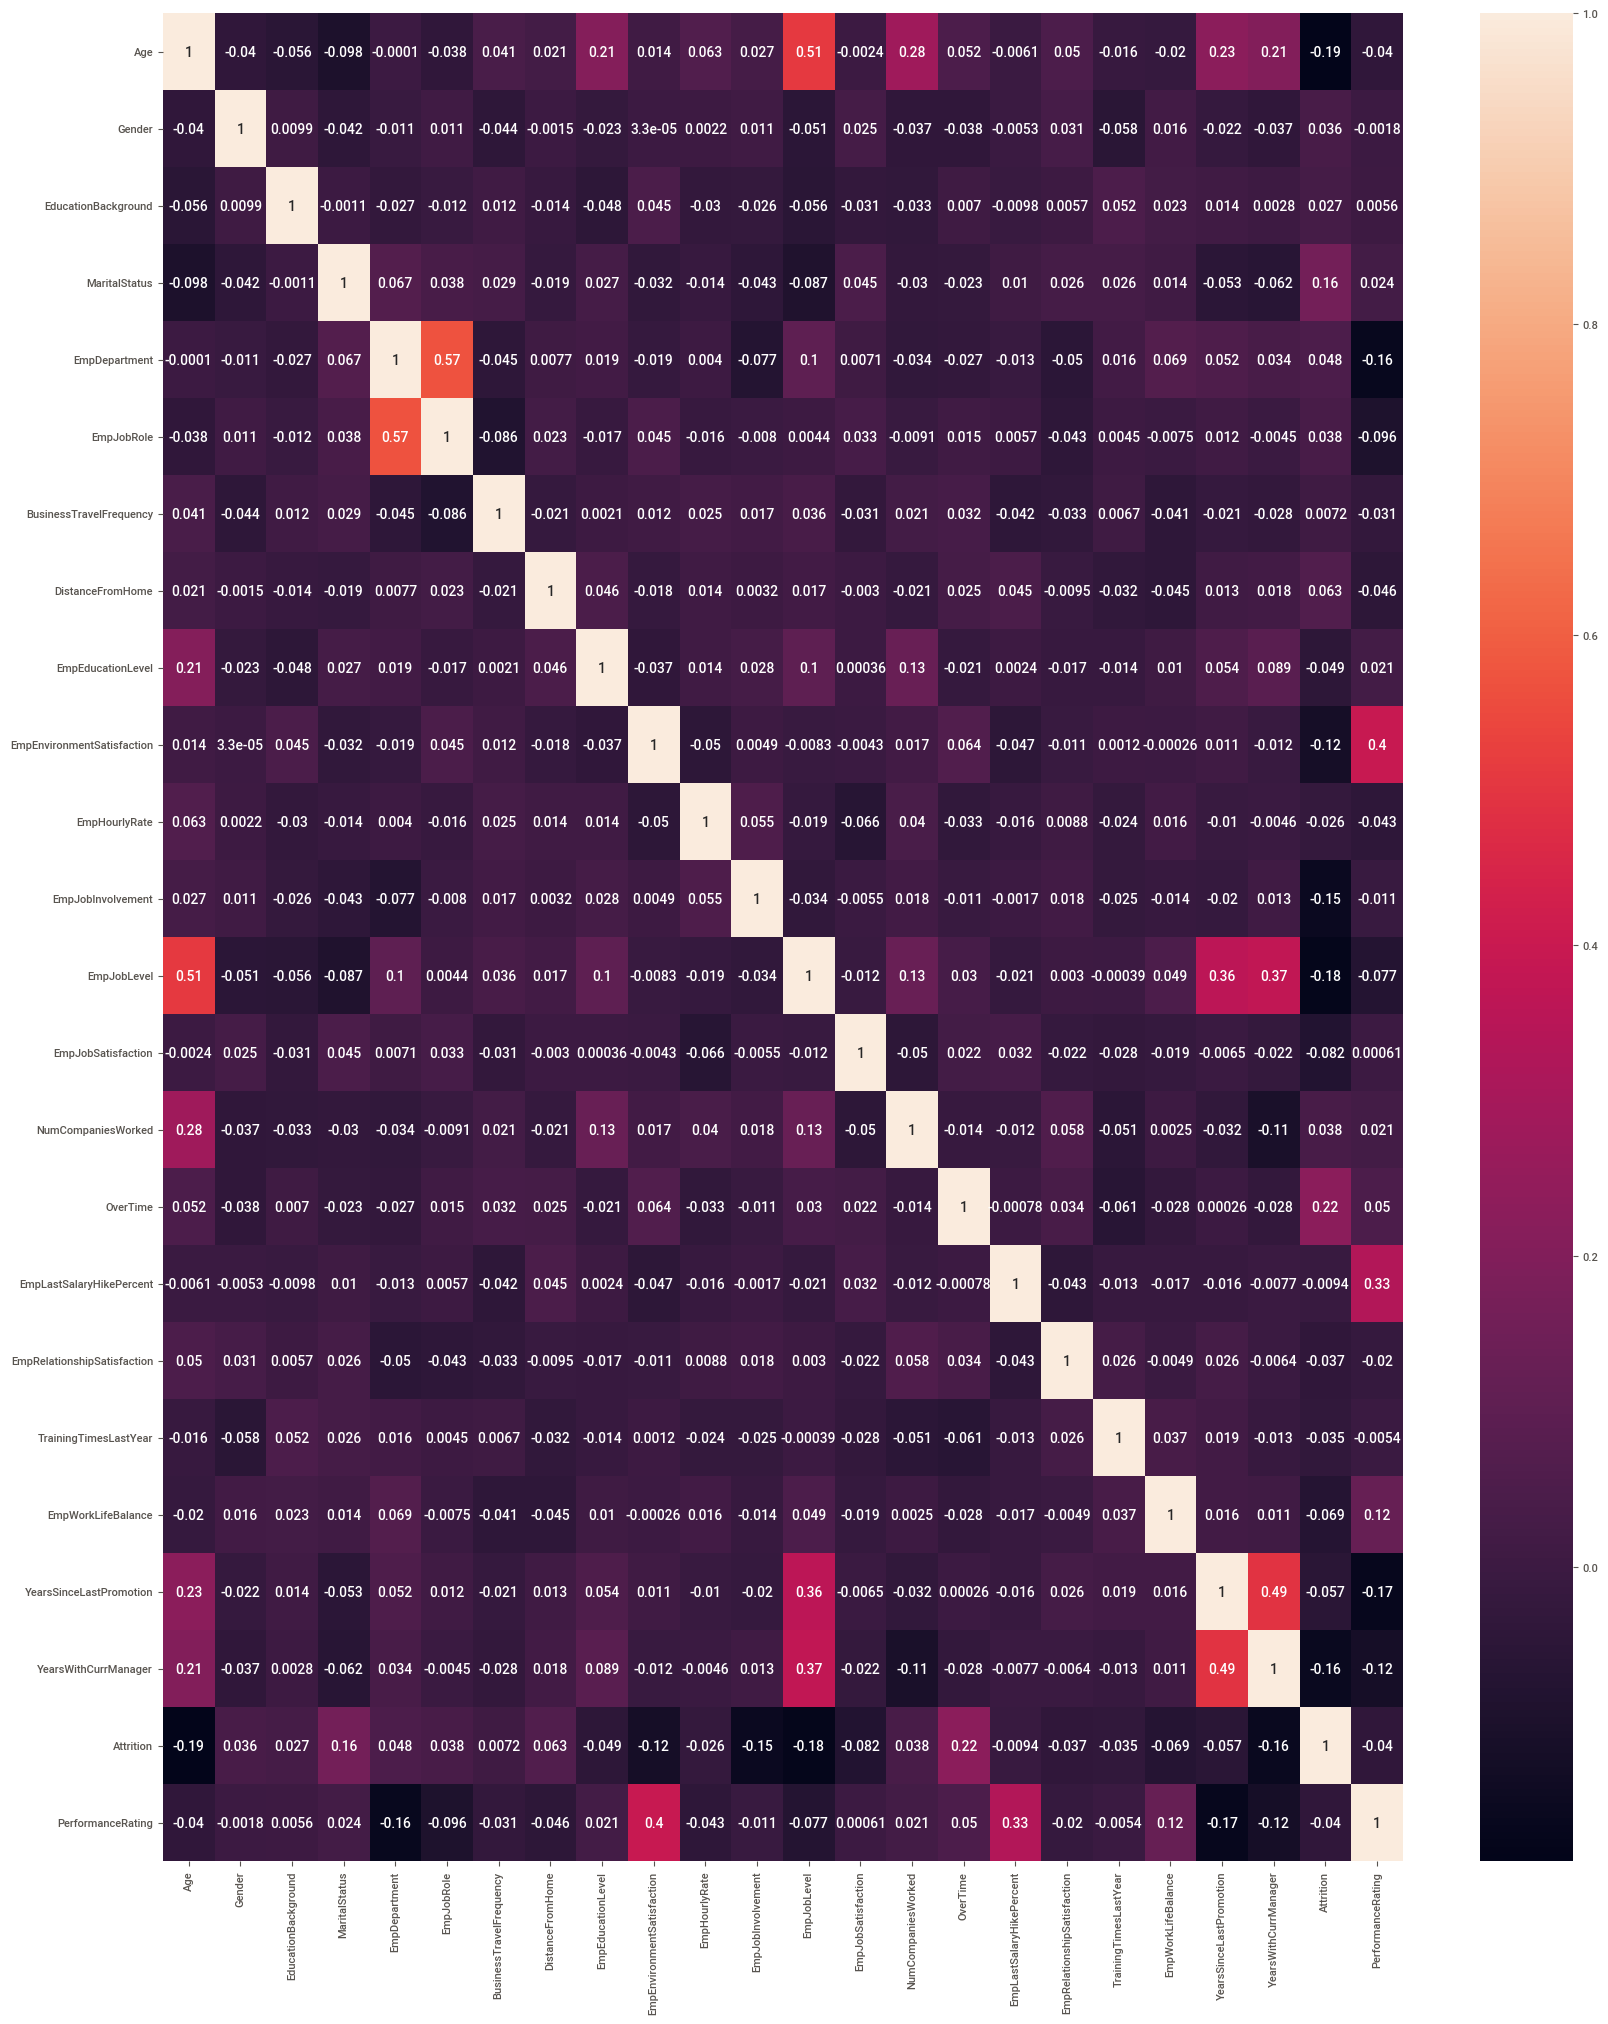

In [38]:
plt.figure(figsize=(20,24))
sns.heatmap(df.corr(), annot= True)
plt.show()

# 9. Split Data

In [39]:
x= df.drop('PerformanceRating', axis=1)
y= df['PerformanceRating']
x.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TrainingTimesLastYear,EmpWorkLifeBalance,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,32,1,2,2,5,13,2,10,3,4,...,4,1,0,12,4,2,2,0,8,0
1,47,1,2,2,5,13,2,14,4,4,...,1,2,0,12,4,2,3,1,7,0
2,40,1,1,1,5,13,1,5,4,4,...,1,5,1,21,3,2,3,1,12,0
3,41,1,0,0,3,8,2,10,4,2,...,4,3,0,15,2,2,2,12,6,0
4,60,1,2,2,5,13,2,16,4,1,...,1,8,0,14,4,1,3,2,2,0


# 10. Training and Testing

In [40]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3,random_state=40)

In [41]:
x_test.shape

(360, 23)

# 11. Balancing Data using SMOTE

In [42]:
# check if data is balanced
df.PerformanceRating.value_counts()

3    874
2    194
4    132
Name: PerformanceRating, dtype: int64

In [43]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable


In [44]:
from imblearn.over_sampling import SMOTE 

In [45]:
sm=SMOTE()
x_sm,y_sm=sm.fit_resample(x_train,y_train) 

In [46]:
from collections import Counter
print("Actual Classes",Counter(y_train))
print("SMOTE Classes",Counter(y_sm))

Actual Classes Counter({3: 631, 2: 120, 4: 89})
SMOTE Classes Counter({2: 631, 3: 631, 4: 631})


# 12. Model Building and Evalution

## a. Logistic Regression

In [47]:
lr=LogisticRegression()
lr.fit(x_sm, y_sm)
y_pred=lr.predict(x_test)
y_train_pred=lr.predict(x_sm)

In [48]:
print('LR Training Score:',lr.score(x_sm,y_sm)*100) # checking the training score

LR Training Score: 82.56735340729001


In [49]:
print('LR Testing Score:', lr.score(x_test,y_test)*100) # Checking the testig score

LR Testing Score: 72.5


In [50]:
# checking accuracy, f1, precision, recall, rou_auc score for training
print('Accuracy_Score:',accuracy_score(y_sm,y_train_pred)*100) 
print('F1_Score:',f1_score(y_sm,y_train_pred, average='micro')*100)
print('Precision_score:',precision_score(y_sm,y_train_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_sm,y_train_pred, average='micro')*100)

Accuracy_Score: 82.56735340729001
F1_Score: 82.56735340729001
Precision_score: 82.56735340729001
Recall_Score: 82.56735340729001


In [51]:
# checking accuracy, f1, precision, recall, rou_auc score for testing
lr_accuracy= accuracy_score(y_test,y_pred)*100
print('Accuracy_Score:',accuracy_score(y_test,y_pred)*100)
print('F1_Score:',f1_score(y_test,y_pred, average='micro')*100)
print('Precision_score:',precision_score(y_test,y_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_test,y_pred, average='micro')*100)

Accuracy_Score: 72.5
F1_Score: 72.50000000000001
Precision_score: 72.5
Recall_Score: 72.5


In [52]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.56      0.57      0.56        74
           3       0.85      0.77      0.81       243
           4       0.48      0.74      0.59        43

    accuracy                           0.73       360
   macro avg       0.63      0.69      0.65       360
weighted avg       0.75      0.72      0.73       360



## b. RandomForestClassifier

In [53]:
RFC=RandomForestClassifier()
RFC.fit(x_sm,y_sm) 
y_pred=RFC.predict(x_test)
y_train_pred=RFC.predict(x_sm)

In [54]:
print('RFC Training Score:',RFC.score(x_sm,y_sm)*100) # checking the training score

RFC Training Score: 100.0


In [55]:
print('RFC Testing Score:', RFC.score(x_test,y_test)*100) # Checking the testig score

RFC Testing Score: 87.22222222222223


In [56]:
# checking accuracy, f1, precision, recall, rou_auc score for training
print('Accuracy_Score:',accuracy_score(y_sm,y_train_pred)*100) 
print('F1_Score:',f1_score(y_sm,y_train_pred, average='micro')*100)
print('Precision_score:',precision_score(y_sm,y_train_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_sm,y_train_pred, average='micro')*100)

Accuracy_Score: 100.0
F1_Score: 100.0
Precision_score: 100.0
Recall_Score: 100.0


In [57]:
# checking accuracy, f1, precision, recall, rou_auc score for testing
RFC_accuracy= accuracy_score(y_test,y_pred)*100
print('Accuracy_Score:',accuracy_score(y_test,y_pred)*100)
print('F1_Score:',f1_score(y_test,y_pred, average='micro')*100)
print('Precision_score:',precision_score(y_test,y_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_test,y_pred, average='micro')*100)

Accuracy_Score: 87.22222222222223
F1_Score: 87.22222222222223
Precision_score: 87.22222222222223
Recall_Score: 87.22222222222223


In [58]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.79      0.81      0.80        74
           3       0.92      0.90      0.91       243
           4       0.75      0.84      0.79        43

    accuracy                           0.87       360
   macro avg       0.82      0.85      0.83       360
weighted avg       0.88      0.87      0.87       360



## c. SVC

In [59]:
svc=SVC()
svc.fit(x_sm,y_sm) 
y_pred=svc.predict(x_test)
y_train_pred=svc.predict(x_sm)

In [60]:
print('svc Training Score:',svc.score(x_sm,y_sm)*100) # checking the training score

svc Training Score: 77.3903856312731


In [61]:
print('svc Testing Score:', svc.score(x_test,y_test)*100) # Checking the testig score

svc Testing Score: 63.33333333333333


In [62]:
# checking accuracy, f1, precision, recall, rou_auc score for training
print('Accuracy_Score:',accuracy_score(y_sm,y_train_pred)*100) 
print('F1_Score:',f1_score(y_sm,y_train_pred, average='micro')*100)
print('Precision_score:',precision_score(y_sm,y_train_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_sm,y_train_pred, average='micro')*100)

Accuracy_Score: 77.3903856312731
F1_Score: 77.39038563127312
Precision_score: 77.3903856312731
Recall_Score: 77.3903856312731


In [63]:
# checking accuracy, f1, precision, recall, rou_auc score for testing
svc_accuracy= accuracy_score(y_test,y_pred)*100
print('Accuracy_Score:',accuracy_score(y_test,y_pred)*100)
print('F1_Score:',f1_score(y_test,y_pred, average='micro')*100)
print('Precision_score:',precision_score(y_test,y_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_test,y_pred, average='micro')*100)

Accuracy_Score: 63.33333333333333
F1_Score: 63.33333333333333
Precision_score: 63.33333333333333
Recall_Score: 63.33333333333333


In [64]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.43      0.55      0.48        74
           3       0.85      0.63      0.72       243
           4       0.40      0.79      0.54        43

    accuracy                           0.63       360
   macro avg       0.56      0.66      0.58       360
weighted avg       0.71      0.63      0.65       360



## d. KNeighborsClassifier

In [65]:
KNN=KNeighborsClassifier()
KNN.fit(x_sm,y_sm) 
y_pred=KNN.predict(x_test)
y_train_pred=KNN.predict(x_sm)

In [66]:
print('KNN Training Score:',KNN.score(x_sm,y_sm)*100) # checking the training score

KNN Training Score: 87.79714738510302


In [67]:
print('KNN Testing Score:', KNN.score(x_test,y_test)*100) # Checking the testig score

KNN Testing Score: 50.55555555555556


In [68]:
# checking accuracy, f1, precision, recall, rou_auc score for training
print('Accuracy_Score:',accuracy_score(y_sm,y_train_pred)*100) 
print('F1_Score:',f1_score(y_sm,y_train_pred, average='micro')*100)
print('Precision_score:',precision_score(y_sm,y_train_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_sm,y_train_pred, average='micro')*100)

Accuracy_Score: 87.79714738510302
F1_Score: 87.79714738510302
Precision_score: 87.79714738510302
Recall_Score: 87.79714738510302


In [69]:
# checking accuracy, f1, precision, recall, rou_auc score for testing
KNN_accuracy= accuracy_score(y_test,y_pred)*100
print('Accuracy_Score:',accuracy_score(y_test,y_pred)*100)
print('F1_Score:',f1_score(y_test,y_pred, average='micro')*100)
print('Precision_score:',precision_score(y_test,y_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_test,y_pred, average='micro')*100)

Accuracy_Score: 50.55555555555556
F1_Score: 50.55555555555556
Precision_score: 50.55555555555556
Recall_Score: 50.55555555555556


In [70]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.28      0.46      0.35        74
           3       0.79      0.51      0.62       243
           4       0.30      0.58      0.40        43

    accuracy                           0.51       360
   macro avg       0.46      0.52      0.45       360
weighted avg       0.63      0.51      0.54       360



## e. DecisionTreeClassifier

In [71]:
dt=DecisionTreeClassifier()
dt.fit(x_sm,y_sm) 
y_pred=dt.predict(x_test)
y_train_pred=dt.predict(x_sm)

In [72]:
print('DT Training Score:',dt.score(x_sm,y_sm)*100) # checking the training score

DT Training Score: 100.0


In [73]:
print('DT Testing Score:', dt.score(x_test,y_test)*100) # Checking the testig score

DT Testing Score: 83.05555555555556


In [74]:
# checking accuracy, f1, precision, recall, rou_auc score for training
print('Accuracy_Score:',accuracy_score(y_sm,y_train_pred)*100) 
print('F1_Score:',f1_score(y_sm,y_train_pred, average='micro')*100)
print('Precision_score:',precision_score(y_sm,y_train_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_sm,y_train_pred, average='micro')*100)

Accuracy_Score: 100.0
F1_Score: 100.0
Precision_score: 100.0
Recall_Score: 100.0


In [75]:
# checking accuracy, f1, precision, recall, rou_auc score for testing
DT_accuracy= accuracy_score(y_test,y_pred)*100
print('Accuracy_Score:',accuracy_score(y_test,y_pred)*100)
print('F1_Score:',f1_score(y_test,y_pred, average='micro')*100)
print('Precision_score:',precision_score(y_test,y_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_test,y_pred, average='micro')*100)

Accuracy_Score: 83.05555555555556
F1_Score: 83.05555555555556
Precision_score: 83.05555555555556
Recall_Score: 83.05555555555556


In [76]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.79      0.70      0.74        74
           3       0.91      0.87      0.89       243
           4       0.59      0.84      0.69        43

    accuracy                           0.83       360
   macro avg       0.76      0.80      0.77       360
weighted avg       0.84      0.83      0.83       360



## f. GradientBoostingClassifier

In [77]:
GBC=GradientBoostingClassifier()
GBC.fit(x_sm,y_sm) 
y_pred=GBC.predict(x_test)
y_train_pred=GBC.predict(x_sm)

In [78]:
print('GBC Training Score:',GBC.score(x_sm,y_sm)*100) # checking the training score

GBC Training Score: 99.31325937665082


In [79]:
print('GBC Testing Score:', GBC.score(x_test,y_test)*100) # Checking the testig score

GBC Testing Score: 85.55555555555556


In [80]:
# checking accuracy, f1, precision, recall, rou_auc score for training
print('Accuracy_Score:',accuracy_score(y_sm,y_train_pred)*100) 
print('F1_Score:',f1_score(y_sm,y_train_pred, average='micro')*100)
print('Precision_score:',precision_score(y_sm,y_train_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_sm,y_train_pred, average='micro')*100)

Accuracy_Score: 99.31325937665082
F1_Score: 99.31325937665082
Precision_score: 99.31325937665082
Recall_Score: 99.31325937665082


In [81]:
# checking accuracy, f1, precision, recall, rou_auc score for testing
GBC_accuracy= accuracy_score(y_test,y_pred)*100
print('Accuracy_Score:',accuracy_score(y_test,y_pred)*100)
print('F1_Score:',f1_score(y_test,y_pred, average='micro')*100)
print('Precision_score:',precision_score(y_test,y_pred, average='micro')*100)
print('Recall_Score:',recall_score(y_test,y_pred, average='micro')*100)

Accuracy_Score: 85.55555555555556
F1_Score: 85.55555555555556
Precision_score: 85.55555555555556
Recall_Score: 85.55555555555556


In [82]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.78      0.81      0.79        74
           3       0.93      0.87      0.90       243
           4       0.65      0.86      0.74        43

    accuracy                           0.86       360
   macro avg       0.79      0.85      0.81       360
weighted avg       0.87      0.86      0.86       360



# 13. Choosing the best Model

- Since this dataset is an issue of someone's life we will consider Recall

In [83]:
models = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest Classifier', 'Support Vector Classifier', 'KNeighborsClassifer', 'Decision Tree Classifier', 'Gradient Boosting Classifier'],
    'Accuracy_Score': [lr_accuracy, RFC_accuracy, svc_accuracy, KNN_accuracy, DT_accuracy, GBC_accuracy],
    'Testing_Score': [lr.score(x_test,y_test), RFC.score(x_test,y_test), svc.score(x_test,y_test), KNN.score(x_test,y_test), dt.score(x_test,y_test), GBC.score(x_test,y_test)],})
models.sort_values(by='Accuracy_Score', ascending=False)

,Model,Accuracy_Score,Testing_Score
1,Random Forest Classifier,87.222222,0.872222
5,Gradient Boosting Classifier,85.555556,0.855556
4,Decision Tree Classifier,83.055556,0.830556
0,Logistic Regression,72.500000,0.725000
2,Support Vector Classifier,63.333333,0.633333
3,KNeighborsClassifer,50.555556,0.505556


# 14. Hyper Parameter Tuning

In [84]:
# Define the hyperparameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': np.arange(100, 1000, 100),
    'max_depth': np.arange(3, 20),
    'min_samples_split': np.arange(2, 11),
    'min_samples_leaf': np.arange(1, 11),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Create the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=40)

# Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    rf_classifier, param_distributions=param_dist, n_iter=100,
    scoring='accuracy', n_jobs=-1, cv=5, random_state=40, verbose=1
)                          

In [85]:
# Fit RandomizedSearchCV to the training data
random_search.fit(x_sm, y_sm)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=40),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                        'min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                        'n_estimators': array([100, 200, 300, 400, 500, 600, 700, 800, 900])},
                   random_state=40, scoring='accuracy', verbose=1)

In [86]:
# Print the best hyperparameters
print("Best Hyperparameters found:")
print(random_search.best_params_)

Best Hyperparameters found:
{'n_estimators': 900, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': 18, 'bootstrap': False}


In [87]:
# Get the best estimator
best_rf_classifier = random_search.best_estimator_

In [88]:
best_rf_classifier

RandomForestClassifier(bootstrap=False, max_depth=18, max_features='log2',
                       min_samples_leaf=3, min_samples_split=3,
                       n_estimators=900, random_state=40)

In [89]:
# Predict on the test set
y_pred = best_rf_classifier.predict(x_test)

In [93]:
 #Evaluate the model
print('Accuracy Score:', accuracy_score(y_test,y_pred)*100)
print('Precision Score:', precision_score(y_test,y_pred, average='micro')*100)
print('Recall Score:', recall_score(y_test,y_pred, average='micro')*100)
print('F1 Score:', f1_score(y_test,y_pred, average='micro')*100)

Accuracy Score: 88.05555555555556
Precision Score: 88.05555555555556
Recall Score: 88.05555555555556
F1 Score: 88.05555555555556


In [94]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           2       0.83      0.84      0.83        74
           3       0.93      0.90      0.91       243
           4       0.73      0.86      0.79        43

    accuracy                           0.88       360
   macro avg       0.83      0.87      0.84       360
weighted avg       0.89      0.88      0.88       360



## Insight:

After tuning the accuracy score has increased to 88%

# 15. Conclusion:

In this project, we applied various machine learning techniques to predict the future performance of the Employees of INX. We used a dataset of 1200 employees records collected from the company INX Future Inc that could predict the future performance of the Employees. The model Random Forest Classifier is able to achieve a training accuracy of 100% and testing accuracy of 88% which was the best accuracy compared to the other models, which significantly improved to 83% after hyper-parameter tuning.

# 16. Model Comparison Report

We tried with several models like Logistic Regression, Gradient Boosting Classifier, Support Vector Classifier, KNN Classifier, Random Forest Classifier. After evaluation, some models performed extremely good while some of the models performed moderately. After comparing all the models we decided to go for Random Forest Classifier as it was giving the best result. We got a high training score which was 100% and a reasonable accuracy score of 87%.

After choosing the best model we decided to go for hyper parameter tuning to boost the score. After tuning the model, the recall score is 88% which indicates that the model's performance increased after tuning.